### Calculation of Carbon contract for Difference (CCfD)-price

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
avg_EUA_2019 = 24.723125       #€/(t*CO2-eq)  (https://icapcarbonaction.com/en/ets-prices)
avg_EUA_2020 = 24.38660287     #€/(t*CO2-eq)
avg_EUA_2021 = 54.15156951     #€/(t*CO2-eq)
avg_EUA_2022 = 80.18404545     #€/(t*CO2-eq)
avg_EUA_2023 = 83.59650224     #€/(t*CO2-eq)

EUA_2024_2050_DKK = np.array([537, 559, 583, 607, 633, 661, 690, 722, 756, 792, 831, 871, 914, 960, 1008, 1059, 1113, 1171, 1232, 1297, 1366, 1440, 1518, 1601, 1689, 1783, 1884])
# https://fm.dk/media/4tkj2o4w/noegletalskatalog_juni-2024.pdf
exchange_rate = 0.1338
EUA_2024_2050_EUR = EUA_2024_2050_DKK * exchange_rate
EUA_2023_2050_EUR = np.insert(EUA_2024_2050_EUR,0, avg_EUA_2023)
EUA_2019_2024_EUR = np.array([avg_EUA_2019, avg_EUA_2020, avg_EUA_2021, avg_EUA_2022, avg_EUA_2023])
EUA_all = np.concatenate((np.array([avg_EUA_2019, avg_EUA_2020, avg_EUA_2021, avg_EUA_2022, avg_EUA_2023]), EUA_2024_2050_EUR), axis=None)


In [37]:
# methanol data for calculations
demand_daily_Wh = 20.1928*10**6                          # Wh
price_methanol = 277.8
#price_methanol = 360                                     # €/tonne        (https://www.methanex.com/sites/default/files/methanol-price/Mx-Price-Sheet%20-%20Jan%2029%2C%202019.pdf)
energy_density = 19.7*10**9                              # J/tonne     
co2_equiv_perkg = 0.723                                  # kg*CO2-eq/(kg Methanol)
co2_equiv_perJ = co2_equiv_perkg/energy_density          # t*CO2-eq/J
print(co2_equiv_perJ)
emissions_of_hub = 0

# Daily demand
demand_daily_J = demand_daily_Wh*3600
demand_daily_t = demand_daily_J/energy_density

# CO2-eq. per daily methanol and per tonne methanol
co2_per_day = co2_equiv * demand_daily_J
co2_per_tonne = co2_per_day / demand_daily_t

# Methanol price excluding CO2 price to have the production costs
costs_methanol = price_methanol - avg_EUA_2019* co2_per_tonne    # €/tonne
daily_costs_conventional_M = costs_methanol * demand_daily_t           # €

# Costs for modelled methanol per day without PV revnue
#daily_costs_renewable_M_2019 = LCOE_t * demand_daily_t                       #€
daily_costs_renewable_M_2019 = 1415.7 * demand_daily_t                        #€
daily_costs_renewable_M_2050 = 962.54 * demand_daily_t                        #€

# Costs for modelled methanol per day with PV revnue
daily_costs_renewable_M_2019_PV = 1121.11 * demand_daily_t                        #€
daily_costs_renewable_M_2050_PV = 755.99 * demand_daily_t                        #€


# Cost and Emission differences 
Delta_costs_2019 = daily_costs_renewable_M_2019 - daily_costs_conventional_M
Delta_costs_2050 = daily_costs_renewable_M_2050 - daily_costs_conventional_M
Delta_emissions = co2_per_day- emissions_of_hub

# Cost and Emission differences with PV revnue
Delta_costs_2019_PV = daily_costs_renewable_M_2019_PV - daily_costs_conventional_M
Delta_costs_2050_PV = daily_costs_renewable_M_2050_PV - daily_costs_conventional_M
Delta_emissions_PV = co2_per_day- emissions_of_hub

# CCfD price
CCfD_2019 = Delta_costs_2019/Delta_emissions
CCfD_2050 = Delta_costs_2050/Delta_emissions

# CCfD price with PV revenue
CCfD_2019_PV = Delta_costs_2019_PV/Delta_emissions
CCfD_2050_PV = Delta_costs_2050_PV/Delta_emissions

# Necessary CO_2 price for 2050 if no CCfD
LCOE_t_2050 = 962.54
price_per_co2_2050 = -(costs_methanol-LCOE_t_2050)/co2_per_tonne 

print(daily_costs_renewable_M_2019, daily_costs_conventional_M, co2_per_day, CCfD_2019)

3.6700507614213195e-11
5224.010611979696 836.38862285167 7.6328784 574.8318994742567


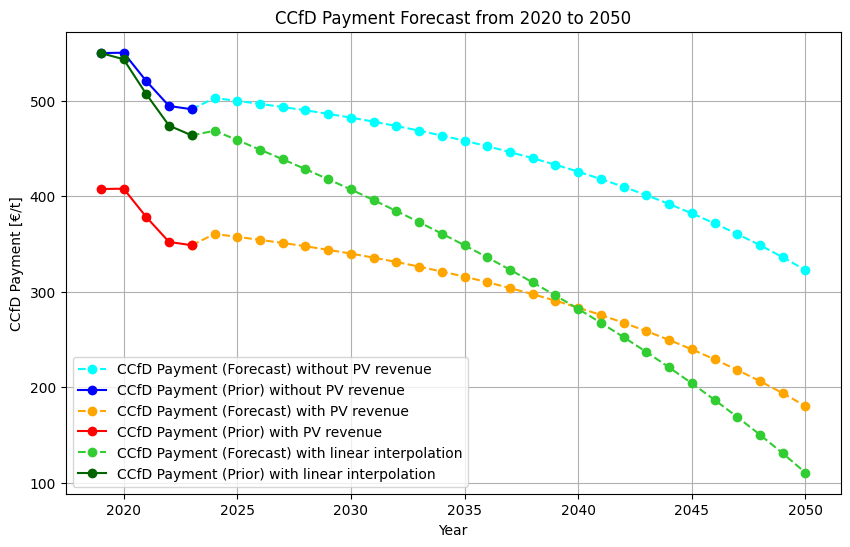

In [17]:
#Plotting CCfD for years 2020-2050
#co2_prices_forecast = np.arange(25, 285, (260/30))

# Without PV
# Array with CCfd of 2019 for every year
CCfD_array_long= np.full(len(EUA_2023_2050_EUR), CCfD_2019)
CCfD_array_short = np.full(len(EUA_2019_2024_EUR), CCfD_2019)

CCfD_payment_forecast = CCfD_array_long - EUA_2023_2050_EUR
CCfD_payment_prior = CCfD_array_short - EUA_2019_2024_EUR

# With PV
# Array with CCfd of 2019 for every year
CCfD_array_long_PV= np.full(len(EUA_2023_2050_EUR), CCfD_2019_PV)
CCfD_array_short_PV = np.full(len(EUA_2019_2024_EUR), CCfD_2019_PV)
CCfD_payment_forecast_PV = CCfD_array_long_PV - EUA_2023_2050_EUR
CCfD_payment_prior_PV = CCfD_array_short_PV - EUA_2019_2024_EUR

# With linear interpolation between CCfD 2019 and 2050
linear_CCfD = np.arange(CCfD_2019, CCfD_2050, ((CCfD_2050-CCfD_2019)/32))
CCfD_array_long_linear= linear_CCfD[4:]
CCfD_array_short_linear = linear_CCfD[:5]
CCfD_payment_forecast_linear = CCfD_array_long_linear - EUA_2023_2050_EUR
CCfD_payment_prior_linear = CCfD_array_short_linear - EUA_2019_2024_EUR

years_prior = np.arange(2019, 2024) 
years_forecast = np.arange(2023, 2051)  # 2023 to 2050


# Plotting the data
plt.figure(figsize=(10, 6))
plt.plot(years_forecast, CCfD_payment_forecast, marker='o', linestyle='--', color='cyan', label="CCfD Payment (Forecast) without PV revenue")
plt.plot(years_prior, CCfD_payment_prior, marker='o', color='blue', label="CCfD Payment (Prior) without PV revenue")

plt.plot(years_forecast, CCfD_payment_forecast_PV, marker='o', linestyle='--', color='orange', label="CCfD Payment (Forecast) with PV revenue")
plt.plot(years_prior, CCfD_payment_prior_PV, marker='o', color='r', label="CCfD Payment (Prior) with PV revenue")

plt.plot(years_forecast, CCfD_payment_forecast_linear, marker='o', linestyle='--', color='limegreen', label="CCfD Payment (Forecast) with linear interpolation")
plt.plot(years_prior, CCfD_payment_prior_linear, marker='o', color='darkgreen', label="CCfD Payment (Prior) with linear interpolation")

plt.xticks(np.arange(2020, 2051, 5))

plt.xlabel("Year")
plt.ylabel("CCfD Payment [€/t]")
plt.title("CCfD Payment Forecast from 2020 to 2050")
plt.legend()
plt.grid(True)
plt.show()



In [38]:
# methanol data for calculations
energy_density = 19.7*10**9                              # J/tonne 

demand_daily_Wh = 20.1928*10**6                          # Wh
demand_daily_J = demand_daily_Wh*3600                    # J
demand_daily_t = demand_daily_J/energy_density           # t

price_methanol_2019 = 277.8
#price_methanol = 360                                     # €/tonne        (https://www.methanex.com/sites/default/files/methanol-price/Mx-Price-Sheet%20-%20Jan%2029%2C%202019.pdf)
    
co2_equiv_per_mass = 0.723                               # kg*CO2-eq/(kg Methanol)
co2_equiv_perJ = co2_equiv_perkg/energy_density          # t*CO2-eq/J
co2_equiv_perWh = co2_equiv_perJ/3600
emissions_of_hub = 0

 

## Methanol from natural gases
# To evaluate the costs of methanol per tonne, we take the market price and subtract the costs caused by the EUA 
costs_per_tonne_2019 = price_methanol_2019 - avg_EUA_2019 * co2_equiv_per_mass
price_methanol_2050 = costs_per_tonne_2019 + EUA_2024_2050_EUR[-1] * co2_equiv_per_mass

# Price of the daily methanol demand for grey methanol
daily_grey_M_2019 = price_methanol_2019 * demand_daily_t
daily_grey_M_2050 = price_methanol_2050 * demand_daily_t

# Emissions of daily methanol demand for grey mathanol
co2_per_day = co2_equiv_perJ * demand_daily_J
co2_per_tonne = co2_per_day / demand_daily_t

## Costs for the hubs' daily demand of green methanol in 2019 and 2050

# Without PV revenue
daily_green_M_2019 = 1415.7 * demand_daily_t                        #€
daily_green_M_2050 = 962.54 * demand_daily_t                        #€

# With PV
daily_green_M_2019_PV = 1121.11 * demand_daily_t                    #€
daily_green_M_2050_PV = 755.99 * demand_daily_t                     #€


# The strike price is calculated using the demand of 1 day (P_strike = (Cost_M- LCOE)/Emissions_M)
P_strike_2019 = (daily_green_M_2019-daily_grey_M_2019)/(co2_per_day-emissions_of_hub)    # Without PV revenue  ([€/t])
P_strike_2019_PV = (daily_green_M_2019_PV-daily_grey_M_2019)/(co2_per_day-emissions_of_hub)    # With PV revenue   ([€/t])

P_strike_2050 = (daily_green_M_2050-daily_grey_M_2050)/(co2_per_day-emissions_of_hub)    # Without PV revenue  ([€/t])
P_strike_2050_PV = (daily_green_M_2050_PV-daily_grey_M_2050)/(co2_per_day-emissions_of_hub)    # With PV revenue   ([€/t])


# Carbon Costs for Difference for 2019 (CCfD = P_strike - P_market )
CCfD_2019 = (P_strike_2019-price_methanol_2019)      # Without PV revenue   ([€/t])
CCfD_2019_PV = (P_strike_2019_PV-price_methanol_2019)      # With PV revenue   ([€/t])

print(daily_grey_M_2019, daily_green_M_2019, co2_per_day, CCfD_2019)
print(daily_costs_renewable_M_2019, daily_costs_conventional_M)

1025.09722964467 5224.010611979696 2.667909636548223 1296.0589211618262
5224.010611979696 836.38862285167


In [34]:
## Future CCfDs

# Forecasted methanol market prices (methanol cost +  EUA * co2_equiv_per_mass)
grey_M_prices = np.full(len(EUA_all),costs_methanol)+ EUA_all*co2_equiv_per_mass
grey_M_prices_pre = grey_M_prices[:len(EUA_2019_2024_EUR)]
grey_M_prices_fc = grey_M_prices[len(EUA_2019_2024_EUR)-1:]

## Strike prices (4 cases)

# Case1: P_strike stays the same as in 2019 and PV revnue is not included

Pstrike1_array_fc= np.full(len(EUA_2023_2050_EUR), P_strike_2019)
Pstrike1_array_pre = np.full(len(EUA_2019_2024_EUR), P_strike_2019)
CCfD_case1_fc = Pstrike1_array_fc - grey_M_prices_fc
CCfD_case1_pre = Pstrike1_array_pre - grey_M_prices_pre


# Case2: P_strike stays the same as in 2019 and PV revnue is included

Pstrike2_array_fc= np.full(len(EUA_2023_2050_EUR), P_strike_2019_PV)
Pstrike2_array_pre = np.full(len(EUA_2019_2024_EUR), P_strike_2019_PV)
CCfD_case2_fc = Pstrike2_array_fc - grey_M_prices_fc
CCfD_case2_pre = Pstrike2_array_pre - grey_M_prices_pre

# Case3: P_strike linearly increases to the value of P_Strike_2050 and PV revnue is not included

Pstrike3_array_full= np.arange(P_strike_2019, P_strike_2050, ((P_strike_2050-P_strike_2019)/32))
Pstrike3_array_pre = Pstrike3_array_full[:len(EUA_2019_2024_EUR)]
Pstrike3_array_fc = Pstrike3_array_full[len(EUA_2019_2024_EUR)-1:]
CCfD_case3_fc = Pstrike3_array_fc - grey_M_prices_fc
CCfD_case3_pre = Pstrike3_array_pre - grey_M_prices_pre

# Case4: P_strike linearly increases to the value of P_Strike_2050 and PV revnue is included
Pstrike4_array_full= np.arange(P_strike_2019_PV, P_strike_2050_PV, ((P_strike_2050_PV-P_strike_2019_PV)/32))
Pstrike4_array_pre = Pstrike4_array_full[:len(EUA_2019_2024_EUR)]
Pstrike4_array_fc = Pstrike4_array_full[len(EUA_2019_2024_EUR)-1:]
CCfD_case4_fc = Pstrike4_array_fc - grey_M_prices_fc
CCfD_case4_pre = Pstrike4_array_pre - grey_M_prices_pre



In [42]:
import matplotlib.colors as mcolors
print(mcolors.CSS4_COLORS)

{'aliceblue': '#F0F8FF', 'antiquewhite': '#FAEBD7', 'aqua': '#00FFFF', 'aquamarine': '#7FFFD4', 'azure': '#F0FFFF', 'beige': '#F5F5DC', 'bisque': '#FFE4C4', 'black': '#000000', 'blanchedalmond': '#FFEBCD', 'blue': '#0000FF', 'blueviolet': '#8A2BE2', 'brown': '#A52A2A', 'burlywood': '#DEB887', 'cadetblue': '#5F9EA0', 'chartreuse': '#7FFF00', 'chocolate': '#D2691E', 'coral': '#FF7F50', 'cornflowerblue': '#6495ED', 'cornsilk': '#FFF8DC', 'crimson': '#DC143C', 'cyan': '#00FFFF', 'darkblue': '#00008B', 'darkcyan': '#008B8B', 'darkgoldenrod': '#B8860B', 'darkgray': '#A9A9A9', 'darkgreen': '#006400', 'darkgrey': '#A9A9A9', 'darkkhaki': '#BDB76B', 'darkmagenta': '#8B008B', 'darkolivegreen': '#556B2F', 'darkorange': '#FF8C00', 'darkorchid': '#9932CC', 'darkred': '#8B0000', 'darksalmon': '#E9967A', 'darkseagreen': '#8FBC8F', 'darkslateblue': '#483D8B', 'darkslategray': '#2F4F4F', 'darkslategrey': '#2F4F4F', 'darkturquoise': '#00CED1', 'darkviolet': '#9400D3', 'deeppink': '#FF1493', 'deepskyblue'

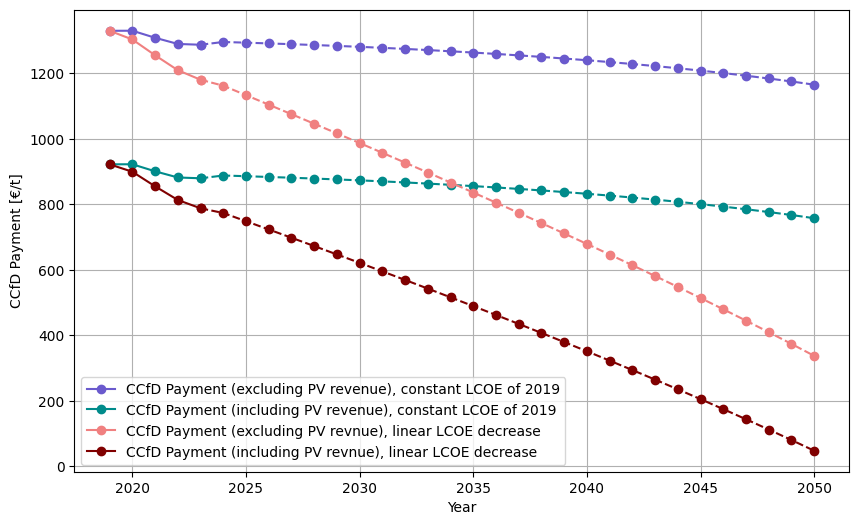

In [49]:
# Plotting the data
plt.figure(figsize=(10, 6))
plt.plot(years_forecast, CCfD_case1_fc, marker='o', linestyle='--', color='#6A5ACD')
plt.plot(years_prior, CCfD_case1_pre, marker='o', color='#6A5ACD', label="CCfD Payment (excluding PV revenue), constant LCOE of 2019")

plt.plot(years_forecast,CCfD_case2_fc, marker='o', linestyle='--', color='darkcyan')
plt.plot(years_prior, CCfD_case2_pre, marker='o', color='darkcyan', label="CCfD Payment (including PV revenue), constant LCOE of 2019")

plt.plot(years_forecast, CCfD_case3_fc, marker='o', linestyle='--', color='lightcoral')
plt.plot(years_prior, CCfD_case3_pre, marker='o', color='lightcoral', label="CCfD Payment (excluding PV revnue), linear LCOE decrease")

plt.plot(years_forecast, CCfD_case4_fc, marker='o', linestyle='--', color='maroon')
plt.plot(years_prior, CCfD_case4_pre, marker='o', color='maroon', label="CCfD Payment (including PV revnue), linear LCOE decrease")



plt.xticks(np.arange(2020, 2051, 5))

plt.xlabel("Year")
plt.ylabel("CCfD Payment [€/t]")
plt.legend()
plt.grid(True)

plt.savefig("CCfD_payments1.png")
plt.show()